# <font color=blue> Detección de caracteristicas y esquinas</font>


**Objetivos:**
Aprender a detectar características y esquinas en imágenes utilizando los algoritmos Shi-Tomasi, Harris, sift, surf y ORB en OpenCV como tambien el maching de imagenes.

## <font color=green> Ejercicio 1:  Importar bibliotecas necesarias</font>

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## <font color=green> Ejercicio 2: Detección de Esquinas Shi-Tomasi</font>

**Objetivo:** Detectar esquinas en una imagen utilizando el método de Shi-Tomasi.
**Pasos:**
1.   Cargar la imagen en escala de grises y a color usando `cv2.imread()`.
2.   Detectar las esquinas con el método Shi-Tomasi usando `cv2.goodFeaturesToTrack()`.
3.   Convertir las esquinas a enteros con `np.intp()`.
4.   Dibujar las esquinas detectadas sobre la imagen original usando `cv2.circle()` con un color.
5.   Visualizar la imagen con las esquinas localizadas sobre la imagen original usando `plt.imshow()`.

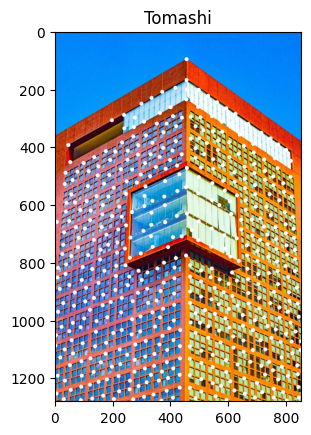

In [66]:
img1 = "C:/Users/HUAWEI/Desktop/TRATAMIENTO/PARCIAL3/3_1_Deteccion_de_caracteristicas_y_esquinas/data/Edificio.jpg"

img1_color = cv2.imread(img1, cv2.IMREAD_COLOR)
img1_gray = cv2.imread(img1, cv2.IMREAD_GRAYSCALE)

tomashi = cv2.goodFeaturesToTrack(img1_gray, maxCorners=500, qualityLevel=0.001, minDistance=30)
tomashi = np.intp(tomashi)

for i in tomashi:
    x, y = i.ravel()
    cv2.circle(img1_color, (x, y), 7, (255, 255, 255), -1)

plt.imshow(cv2.cvtColor(img1_color, cv2.COLOR_BGR2RGB))
plt.title("Tomashi")
plt.show()


## <font color=green> Ejercicio 3: Detección de Esquinas con Harris Corner Detector </font>

**Objetivo:** Detectar esquinas en una imagen utilizando el método de Harris Corner Detector.

**Pasos:**
1.   Cargar la imagen en escala de grises usando `cv2.imread()`.
2.   Convertir la imagen a tipo flotante con `np.float32()` para poder aplicar el detector de Harris.
3.   Usar `cv2.cornerHarris()` para detectar esquinas mediante el método de Harris.
4.   Dibujar las esquinas detectadas sobre la imagen original, resaltándolas en color.
5.   Visualizar la imagen con las esquinas localizadas sobre la imagen original con `plt.imshow()`.

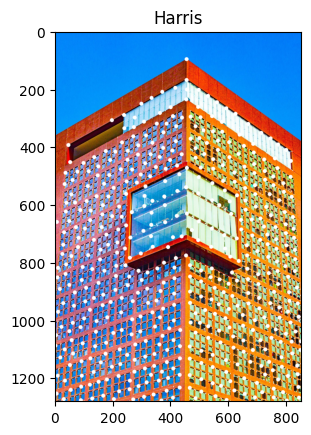

In [67]:
gray_float = np.float32(img1_gray)
harris = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)

img_h = img1_color.copy()
img_h[harris > 0.01 * harris.max()] = [255, 255, 255]

plt.imshow(cv2.cvtColor(img_h, cv2.COLOR_BGR2RGB))
plt.title("Harris")
plt.show()

## <font color=green> Ejercicio 4:  Detección de Características con SIFT </font>

**Objetivo:** Detectar puntos clave y descriptores en una imagen utilizando SIFT (Scale-Invariant Feature Transform).

**Pasos:**
1.  Cargar la imagen en escala de grises y a color usando `cv2.imread()`.
2.  Crear el objeto SIFT con `cv2.SIFT_create()`.
3.  Detectar los puntos clave y sus descriptores usando el método `detectAndCompute()` de SIFT.
4.  Dibujar los puntos clave detectados sobre la imagen original con `cv2.drawKeypoints()`, usando un color.
5.  Visualizar la imagen con las características localizadas sobre la imagen original usando `plt.imshow()`.

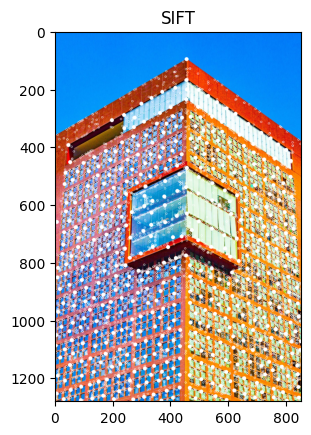

In [68]:
sift = cv2.SIFT_create()

kp, ds = sift.detectAndCompute(img1_gray, None)

img_sift = cv2.drawKeypoints(img1_color, kp, None, color=(255, 255, 255))

plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title("SIFT")
plt.show()

## <font color=green> Ejercicio 5:  Detección de Características con BRISK </font>

**Objetivo:** Detectar puntos clave y descriptores con BRISK (Binary Robust Invariant Scalable Keypoints).

**Pasos:**
1.   Crear el objeto BRISK usando `cv2.BRISK_create()`.
2.   Detectar los puntos clave y sus descriptores usando el método `detectAndCompute()` de BRISK.
3.   Dibujar los puntos clave detectados sobre la imagen original con `cv2.drawKeypoints()`, usando un color.
4.   Visualizar la imagen con las características localizadas sobre la imagen original usando `plt.imshow()`.






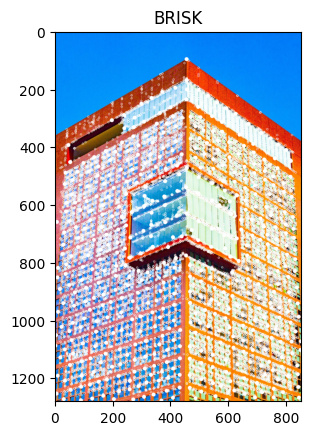

In [69]:
brisk = cv2.BRISK_create()

kp, ds = brisk.detectAndCompute(img1_gray, None)

img_brisk = cv2.drawKeypoints(img1_color, kp, None, color=(255, 255, 255))

plt.imshow(cv2.cvtColor(img_brisk, cv2.COLOR_BGR2RGB))
plt.title("BRISK")
plt.show()

## <font color=green> Ejercicio 6:  Detección de Características con ORB </font>

**Objetivo:** Detectar puntos clave y descriptores con ORB (Oriented FAST and Rotated BRIEF).

**Pasos:**
1.   Crear el objeto ORB usando `cv2.ORB_create()` y definir el número de características a detectar.
2.   Dibujar los puntos clave detectados sobre la imagen original con `cv2.drawKeypoints()`, usando un color.
3.   Visualizar la imagen con las características localizadas sobre la imagen original usando `plt.imshow()`.

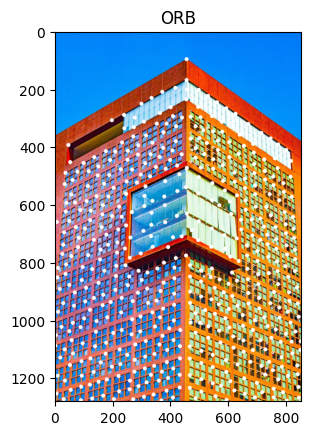

In [70]:
orb = cv2.ORB_create(nfeatures=500)

kp, ds = orb.detectAndCompute(img1_gray, None)

img_orb = cv2.drawKeypoints(img1_color, kp, None, color=(255, 255, 255))

plt.imshow(cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB))
plt.title("ORB")
plt.show()

## <font color=green> Ejercicio 7:  Maching de Características </font>

**Objetivo:** Aprender a comparar y emparejar características entre dos imágenes utilizando descriptores SIFT, ORB o BRISK y el algoritmo BFMatcher (Brute-Force Matcher) en OpenCV.

**Pasos:**
1.   Crear el detector de características para SIFT, ORB y BRISK.
2.   Detectar puntos clave y descriptores en ambas imágenes usando `detectAndCompute()`.
3.   Verificar que se hayan detectado suficientes características para continuar con la comparación.
4.   Crear el objeto de comparación de características (Matcher): `cv2.BFMatcher()` para ORB, SIFT y BRISK.
5.   Realizar el emparejamiento de descriptores con `bf.match()` y ordenar las coincidencias por distancia.
6.   Dibujar las mejores coincidencias entre ambas imágenes usando `cv2.drawMatches()`.
7.   Visualizar el resultado del emparejamiento de características usando `plt.imshow()`.

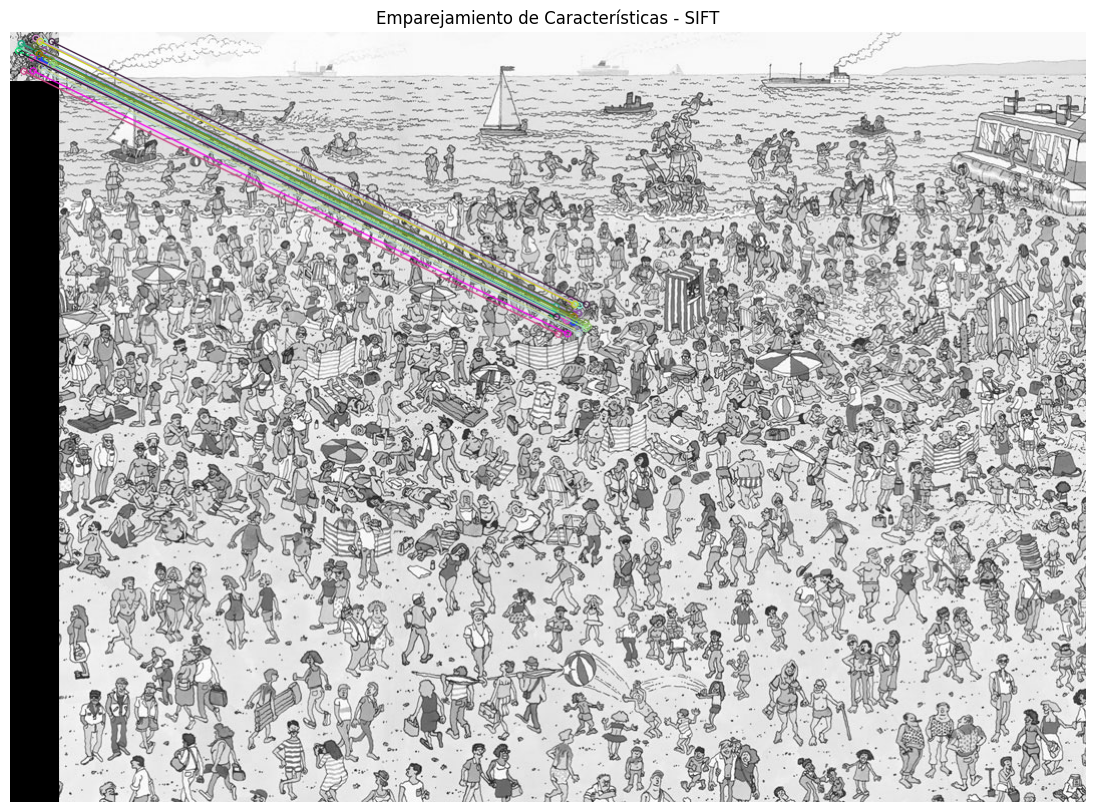

In [83]:
img2 = "C:/Users/HUAWEI/Desktop/TRATAMIENTO/PARCIAL3/3_1_Deteccion_de_caracteristicas_y_esquinas/data/waldo.jpg"
img3 = "C:/Users/HUAWEI/Desktop/TRATAMIENTO/PARCIAL3/3_1_Deteccion_de_caracteristicas_y_esquinas/data/WaldoBeach.jpg"

img2 = cv2.imread(img2, cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread(img3, cv2.IMREAD_GRAYSCALE)

method = "SIFT"

if method == "SIFT":
    detector = cv2.SIFT_create()
elif method == "ORB":
    detector = cv2.ORB_create(nfeatures=500)
elif method == "BRISK":
    detector = cv2.BRISK_create()
else:
    raise ValueError("Método no válido. Usa 'SIFT', 'ORB' o 'BRISK'.")

keypoints1, descriptors1 = detector.detectAndCompute(img2, None)
keypoints2, descriptors2 = detector.detectAndCompute(img3, None)

if descriptors1 is None or descriptors2 is None:
    print("No se detectaron suficientes características en una de las imágenes.")
else:
    if method == "ORB":
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    else:
        bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

    matches = bf.match(descriptors1, descriptors2)
    matches = sorted(matches, key=lambda x: x.distance)

    matched_image = cv2.drawMatches(img2, keypoints1, img3, keypoints2, matches[:30], None, flags=2)

    plt.figure(figsize=(15, 10))
    plt.imshow(matched_image, cmap="gray")
    plt.title(f"Emparejamiento de Características - {method}")
    plt.axis("off")
    plt.show()